In [1]:
import json

# 打开文件并读取数据
with open('fine-tuned-models/nllb-200-distilled-600M/zh2ko_1031/trainer_state.json', 'r') as f:
    data = json.load(f)

data

{'best_metric': 0.016907043755054474,
 'best_model_checkpoint': 'autodl-tmp/nllb-200-distilled-600M/zh2ko_1031/checkpoint-120000',
 'epoch': 1.935265373264309,
 'global_step': 120000,
 'is_hyper_param_search': False,
 'is_local_process_zero': True,
 'is_world_process_zero': True,
 'log_history': [{'epoch': 0.08,
   'learning_rate': 4.024545615817569e-06,
   'loss': 7.6369,
   'step': 5000},
  {'epoch': 0.08,
   'eval_loss': 1.2060621976852417,
   'eval_runtime': 625.2893,
   'eval_samples_per_second': 24.792,
   'eval_steps_per_second': 24.792,
   'step': 5000},
  {'epoch': 0.16,
   'learning_rate': 8.056348476784879e-06,
   'loss': 0.1697,
   'step': 10000},
  {'epoch': 0.16,
   'eval_loss': 0.04592869058251381,
   'eval_runtime': 634.1858,
   'eval_samples_per_second': 24.444,
   'eval_steps_per_second': 24.444,
   'step': 10000},
  {'epoch': 0.24,
   'learning_rate': 1.208815133775219e-05,
   'loss': 0.0412,
   'step': 15000},
  {'epoch': 0.24,
   'eval_loss': 0.03297297656536102,
 

In [2]:
import pandas as pd

df = pd.DataFrame(data["log_history"])
df

,epoch,learning_rate,loss,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second
0,0.08,0.000004,7.6369,5000,NaN,NaN,NaN,NaN
1,0.08,NaN,NaN,5000,1.206062,625.2893,24.792,24.792
2,0.16,0.000008,0.1697,10000,NaN,NaN,NaN,NaN
3,0.16,NaN,NaN,10000,0.045929,634.1858,24.444,24.444
4,0.24,0.000012,0.0412,15000,NaN,NaN,NaN,NaN
5,0.24,NaN,NaN,15000,0.032973,636.1666,24.368,24.368
6,0.32,0.000016,0.0341,20000,NaN,NaN,NaN,NaN
7,0.32,NaN,NaN,20000,0.028944,639.4799,24.242,24.242
8,0.40,0.000020,0.0299,25000,NaN,NaN,NaN,NaN
9,0.40,NaN,NaN,25000,0.026612,639.4427,24.243,24.243


In [3]:
df.set_index('epoch', inplace=True)
df = df.groupby(level=0).first()
df.reset_index(inplace=True)
df

,epoch,learning_rate,loss,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second
0,0.08,0.000004,7.6369,5000,1.206062,625.2893,24.792,24.792
1,0.16,0.000008,0.1697,10000,0.045929,634.1858,24.444,24.444
2,0.24,0.000012,0.0412,15000,0.032973,636.1666,24.368,24.368
3,0.32,0.000016,0.0341,20000,0.028944,639.4799,24.242,24.242
4,0.40,0.000020,0.0299,25000,0.026612,639.4427,24.243,24.243
5,0.48,0.000024,0.0288,30000,0.024495,635.7904,24.382,24.382
6,0.56,0.000028,0.0265,35000,0.023511,634.9638,24.414,24.414
7,0.65,0.000032,0.0239,40000,0.022301,644.9418,24.036,24.036
8,0.73,0.000036,0.0238,45000,0.021713,644.1225,24.067,24.067
9,0.81,0.000040,0.0231,50000,0.021068,643.1255,24.104,24.104


In [4]:
df = df.iloc[1:]
df

,epoch,learning_rate,loss,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second
1,0.16,0.000008,0.1697,10000,0.045929,634.1858,24.444,24.444
2,0.24,0.000012,0.0412,15000,0.032973,636.1666,24.368,24.368
3,0.32,0.000016,0.0341,20000,0.028944,639.4799,24.242,24.242
4,0.40,0.000020,0.0299,25000,0.026612,639.4427,24.243,24.243
5,0.48,0.000024,0.0288,30000,0.024495,635.7904,24.382,24.382
6,0.56,0.000028,0.0265,35000,0.023511,634.9638,24.414,24.414
7,0.65,0.000032,0.0239,40000,0.022301,644.9418,24.036,24.036
8,0.73,0.000036,0.0238,45000,0.021713,644.1225,24.067,24.067
9,0.81,0.000040,0.0231,50000,0.021068,643.1255,24.104,24.104
10,0.89,0.000044,0.0230,55000,0.020643,626.5487,24.742,24.742


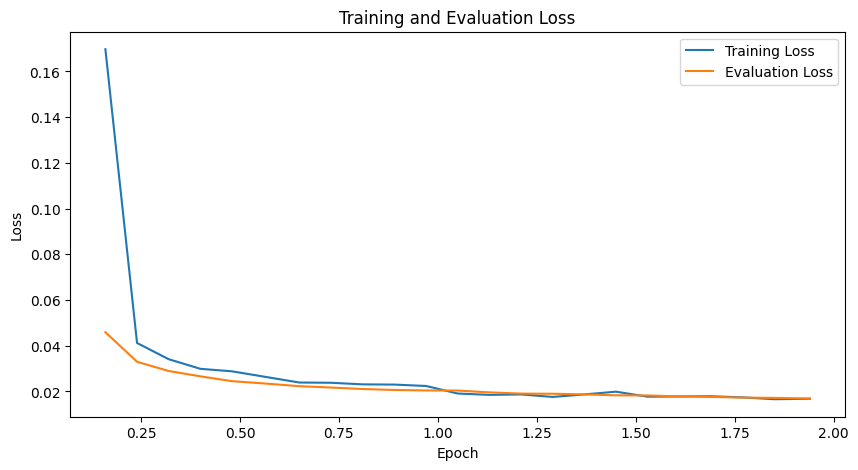

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df['epoch'], df['loss'], label='Training Loss')
plt.plot(df['epoch'], df['eval_loss'], label='Evaluation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Evaluation Loss')
plt.legend()
plt.show()